# <center>Creating baseline Model</center>

## <center> Importing Libraries </center>

In [54]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Machine Learning Models
from sklearn.linear_model import LinearRegression

# Evaluation Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Configuring the Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

# Model saving
import joblib
import pickle




## <center>Loading the Dataset</center>

In [55]:
# Loading the dataset
df = pd.read_csv('../data/processed/checkin_queue_cleaned.csv')
print(f"Dataset loaded successfully!")
print(f"Shape: {df.shape[0]} rows and {df.shape[1]} columns")
print(f"\nFirst 5 rows of the dataset:")
print(df.head())

Dataset loaded successfully!
Shape: 3856 rows and 12 columns

First 5 rows of the dataset:
     Sector    Airline  Pax_In_Line  PAX_Served  Counters  Queue_Agent  \
0  Domestic  Ariline 2         13.0           4         3            0   
1  Domestic  Ariline 1          1.0           3         6            0   
2  Domestic  Ariline 1         10.0           3         9            1   
3  Domestic  Ariline 2          0.0           1        10            1   
4  Domestic  Ariline 3          4.0           2         5            0   

   PAX_Left  Flight_Cancelled  Carousel_Stoped Period_of_Day  Total_Time  \
0         0                 0                0     Afternoon   20.116667   
1         0                 0                0     Afternoon    6.000000   
2         0                 0                0       Morning   19.116667   
3         0                 0                0       Evening   13.833333   
4         0                 0                0     Afternoon    2.766667   

   Tota

In [56]:
# Analyzing data types
print(f"\nData types of each column:")
print(df.dtypes)


Data types of each column:
Sector                 object
Airline                object
Pax_In_Line           float64
PAX_Served              int64
Counters                int64
Queue_Agent             int64
PAX_Left                int64
Flight_Cancelled        int64
Carousel_Stoped         int64
Period_of_Day          object
Total_Time            float64
Total_Checked_Bags    float64
dtype: object


## <center> Analyzing Target Column </center>

In [57]:
# describing the target variable Total_Time
print(f"\nDescriptive statistics for the target variable 'Total_Time':")
print(df['Total_Time'].describe())


Descriptive statistics for the target variable 'Total_Time':
count    3856.000000
mean        8.913045
std         6.311406
min         0.616667
25%         4.016667
50%         7.075000
75%        12.337500
max        28.666667
Name: Total_Time, dtype: float64


In [58]:
# Checking for missing values
print(f"\nMissing values in Total_Time column:")
print(df['Total_Time'].isnull().sum())


Missing values in Total_Time column:
0


## <center> Preparing Features and Target </center>

In [59]:
target_column = 'Total_Time'

In [60]:
# Separating features and target variable
X = df.drop(columns=[target_column])
y = df[target_column]

In [61]:
# Evaluating
print(f"\nShape of features (X): {X.shape}")
print(f"Shape of target variable (y): {y.shape}")


Shape of features (X): (3856, 11)
Shape of target variable (y): (3856,)


In [62]:
print(f'\nFeatures in the dataset:')
print(X.columns.tolist())


Features in the dataset:
['Sector', 'Airline', 'Pax_In_Line', 'PAX_Served', 'Counters', 'Queue_Agent', 'PAX_Left', 'Flight_Cancelled', 'Carousel_Stoped', 'Period_of_Day', 'Total_Checked_Bags']


## <center> Identifying categorical vs numerical features </center>

In [63]:
# Identifying categorial features
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

In [64]:
print(f'categorical features ({len(categorical_features)}):')
for feat in categorical_features:
    unique_count = X[feat].nunique()
    print(f" - {feat:25s} ({unique_count} categories)")

categorical features (3):
 - Sector                    (2 categories)
 - Airline                   (10 categories)
 - Period_of_Day             (4 categories)


In [65]:
print(f"\nNumerical features ({len(numerical_features)}):")
for feat in numerical_features:
    print(f"  - {feat:25s} (range: {X[feat].min():.1f} to {X[feat].max():.1f})")


Numerical features (8):
  - Pax_In_Line               (range: 0.0 to 55.0)
  - PAX_Served                (range: 1.0 to 8.0)
  - Counters                  (range: 1.0 to 12.0)
  - Queue_Agent               (range: 0.0 to 1.0)
  - PAX_Left                  (range: 0.0 to 1.0)
  - Flight_Cancelled          (range: 0.0 to 1.0)
  - Carousel_Stoped           (range: 0.0 to 1.0)
  - Total_Checked_Bags        (range: 0.0 to 7.0)


## <center> Split data into Training and Testing Sets </center>

In [66]:
# Splitting the dataset into training and testing sets 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

In [67]:
# Evaluating the training set
print(f"\nTraining set shape: {X_train.shape}, {y_train.shape}")
print(f"Testing set shape: {X_test.shape}, {y_test.shape}")


Training set shape: (3084, 11), (3084,)
Testing set shape: (772, 11), (772,)


## <center> Encoding the categorical features and scaling numerical features</center>

In [68]:
# Separating binary features
binary_features = [col for col in numerical_features if X[col].nunique() == 2 and set(X[col].unique()).issubset({0, 1})]
print(f"\nBinary features ({len(binary_features)}): {binary_features}")


Binary features (4): ['Queue_Agent', 'PAX_Left', 'Flight_Cancelled', 'Carousel_Stoped']


In [69]:
# Separating numerical features (excluding binary)
numerical_to_scale = [col for col in numerical_features if col not in binary_features]

In [70]:
print(f"\nBinary features (no scaling needed): {binary_features}")
print(f"Numerical features to scale: {numerical_to_scale}")
print(f"Categorical features to encode: {categorical_features}")


Binary features (no scaling needed): ['Queue_Agent', 'PAX_Left', 'Flight_Cancelled', 'Carousel_Stoped']
Numerical features to scale: ['Pax_In_Line', 'PAX_Served', 'Counters', 'Total_Checked_Bags']
Categorical features to encode: ['Sector', 'Airline', 'Period_of_Day']


In [71]:
# Creating the preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_to_scale), # Scaling numerical
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features), #Encoding categorical
        ('binary', 'passthrough', binary_features) # Keeping binary features as they are
    ],
    remainder='drop' # Dropping any other columns not specified in the transformers
)

print(f"\nPreprocessing pipeline created successfully!")


Preprocessing pipeline created successfully!


## <center> Fitting preprocessor on training data </center>

In [72]:
X_train_processed = preprocessor.fit_transform(X_train)

print(f'Training data processed!')
print(f'Original shape: {X_train.shape}')
print(f'Processed shape: {X_train_processed.shape}')

Training data processed!
Original shape: (3084, 11)
Processed shape: (3084, 21)


In [73]:
# Getting feature names after preprocessing
feature_names = []

# Adding scaled numerical feature names
feature_names.extend(numerical_to_scale)

# Adding one-hot encoded categorical feature names
ohe = preprocessor.named_transformers_['cat']
cat_feature_names = ohe.get_feature_names_out(categorical_features)
feature_names.extend(cat_feature_names)

# Adding binary feature names
feature_names.extend(binary_features)

print(f'\nTotal features after encoding: {len(feature_names)}')
print(f'\nNew Features names:')
for i, name in enumerate(feature_names):
    print(f"{i:2d}. {name}")


Total features after encoding: 21

New Features names:
 0. Pax_In_Line
 1. PAX_Served
 2. Counters
 3. Total_Checked_Bags
 4. Sector_International
 5. Airline_Ariline 10
 6. Airline_Ariline 2
 7. Airline_Ariline 3
 8. Airline_Ariline 4
 9. Airline_Ariline 5
10. Airline_Ariline 6
11. Airline_Ariline 7
12. Airline_Ariline 8
13. Airline_Ariline 9
14. Period_of_Day_Evening
15. Period_of_Day_Morning
16. Period_of_Day_Night
17. Queue_Agent
18. PAX_Left
19. Flight_Cancelled
20. Carousel_Stoped


## <center> Transform Test Data </center>

In [74]:
X_test_processed = preprocessor.transform(X_test)
print(f'Testing data processed!')
print(f'Original shape: {X_test.shape}')
print(f'Processed shape: {X_test_processed.shape}')

Testing data processed!
Original shape: (772, 11)
Processed shape: (772, 21)


## <center> Training the linear regression model </center>

In [75]:
model = LinearRegression()
print(f"Model created with default parameters: {model.get_params()}")

Model created with default parameters: {'copy_X': True, 'fit_intercept': True, 'n_jobs': None, 'positive': False}


In [76]:
print(f"Training the model on the processed training data...")
print(f"Model training completed successfully!")
model.fit(X_train_processed, y_train)

Training the model on the processed training data...
Model training completed successfully!


LinearRegression()

## <center> Making Predictions </center>

In [77]:
y_train_pred = model.predict(X_train_processed)
print(f"Predictions on training data completed successfully!")

Predictions on training data completed successfully!


In [78]:
y_test_pred = model.predict(X_test_processed)
print(f"Predictions on testing data completed successfully!")

Predictions on testing data completed successfully!


In [79]:
print(f"Predictions generated successfully for both training and testing sets!")
print(f"Training predictions: {len(y_train_pred)}")
print(f"Testing predictions: {len(y_test_pred)}")

Predictions generated successfully for both training and testing sets!
Training predictions: 3084
Testing predictions: 772


In [80]:
print(f"\nSample predictions (first 10 test records):")
print(f"{'Actual':>10s} | {'Predicted':>10s} | {'Error':>10s}")
print("-" * 40)
for i in range(min(10, len(y_test))):
    actual = y_test.iloc[i]
    predicted = y_test_pred[i]
    error = actual - predicted
    print(f"{actual:10.2f} | {predicted:10.2f} | {error:10.2f}")


Sample predictions (first 10 test records):
    Actual |  Predicted |      Error
----------------------------------------
      5.85 |       6.02 |      -0.17
      2.18 |       5.19 |      -3.01
      7.12 |       7.94 |      -0.82
      8.10 |       7.90 |       0.20
      4.38 |       6.85 |      -2.46
      5.92 |       6.38 |      -0.46
     13.33 |      15.97 |      -2.63
      8.78 |      19.69 |     -10.91
      7.45 |       8.52 |      -1.07
     11.28 |       6.07 |       5.22


## <center> Evaluating Model Performance </center>

In [81]:
# Calculating metrics for training set
train_mae = mean_absolute_error(y_train, y_train_pred)
train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = np.sqrt(train_mse)
train_r2 = r2_score(y_train, y_train_pred)

In [82]:
# Calculating metrics for test set
test_mae = mean_absolute_error(y_test, y_test_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(y_test, y_test_pred)

In [83]:
# Calculating MAPE (Mean Absolute Percentage Error)
train_mape = np.mean(np.abs((y_train - y_train_pred) / y_train)) * 100
test_mape = np.mean(np.abs((y_test - y_test_pred) / y_test)) * 100

In [84]:
# Evaluating training set performance
print("\nTRAINING SET PERFORMANCE")
print("-" * 80)
print(f"MAE (Mean Absolute Error):     {train_mae:.4f} minutes")
print(f"RMSE (Root Mean Squared Error): {train_rmse:.4f} minutes")
print(f"R² Score:                       {train_r2:.4f} ({train_r2*100:.2f}% variance explained)")
print(f"MAPE (Mean Absolute % Error):   {train_mape:.2f}%")


TRAINING SET PERFORMANCE
--------------------------------------------------------------------------------
MAE (Mean Absolute Error):     3.3093 minutes
RMSE (Root Mean Squared Error): 4.4592 minutes
R² Score:                       0.5066 (50.66% variance explained)
MAPE (Mean Absolute % Error):   55.24%


In [85]:
# Evaluating test set performance
print("\nTEST SET PERFORMANCE")
print("-" * 80)
print(f"MAE (Mean Absolute Error):     {test_mae:.4f} minutes")
print(f"RMSE (Root Mean Squared Error): {test_rmse:.4f} minutes")
print(f"R² Score:                       {test_r2:.4f} ({test_r2*100:.2f}% variance explained)")
print(f"MAPE (Mean Absolute % Error):   {test_mape:.2f}%")


TEST SET PERFORMANCE
--------------------------------------------------------------------------------
MAE (Mean Absolute Error):     3.4540 minutes
RMSE (Root Mean Squared Error): 4.5660 minutes
R² Score:                       0.4500 (45.00% variance explained)
MAPE (Mean Absolute % Error):   61.57%


In [86]:
#Evaluating generalization by comparing training and testing performance
print("\nGENERALIZATION CHECK")
print("-" * 80)
overfitting_gap = train_r2 - test_r2
print(f"R² difference (Train - Test):  {overfitting_gap:.4f}")

if overfitting_gap < 0.05:
    print("Excellent! Model generalizes well (minimal overfitting)")
elif overfitting_gap < 0.10:
    print("Good! Model shows acceptable generalization")
elif overfitting_gap < 0.20:
    print("Moderate overfitting detected")
else:
    print("Significant overfitting! Model memorizing training data")


GENERALIZATION CHECK
--------------------------------------------------------------------------------
R² difference (Train - Test):  0.0566
Good! Model shows acceptable generalization


## <center> Interpretation of the model </center>

In [87]:
# Interpretating Results
print("\nINTERPRETATION")
print("-" * 80)
print(f"On average, predictions are off by {test_mae:.2f} minutes (MAE)")
print(f"The model explains {test_r2*100:.1f}% of the variance in Total_Time")
print(f"Typical prediction error is around {test_mape:.1f}% (MAPE)")


INTERPRETATION
--------------------------------------------------------------------------------
On average, predictions are off by 3.45 minutes (MAE)
The model explains 45.0% of the variance in Total_Time
Typical prediction error is around 61.6% (MAPE)


In [88]:
# Analyzing Model Coefficients
coefficients = model.coef_
intercept = model.intercept_

In [89]:
print(f"Intercept (baseline prediction): {intercept:.4f} minutes")
print(f"\nFeature Coefficients:")
print(f"{'Feature':40s} | {'Coefficient':>12s} | {'Effect':>30s}")

# creating a dataframe of coefficients for better visualization
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

# sort by absolute value to see most important features
coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values(by='Abs_Coefficient', ascending=False)

# Displaying the coefficients with their effects
for index, row in coef_df.iterrows():
    feature = row['Feature']
    coef = row['Coefficient']
    
    if coef > 0:
        impact = f"Increases Total_Time by {abs(coef):.4f} minutes"
    else:
        impact = f"Decreases Total_Time by {abs(coef):.4f} minutes"
    print(f"{feature:40s} | {coef:12.4f} | {impact:30s}")

Intercept (baseline prediction): 9.0390 minutes

Feature Coefficients:
Feature                                  |  Coefficient |                         Effect
Airline_Ariline 10                       |       6.6321 | Increases Total_Time by 6.6321 minutes
Airline_Ariline 7                        |      -4.7793 | Decreases Total_Time by 4.7793 minutes
Flight_Cancelled                         |       4.6706 | Increases Total_Time by 4.6706 minutes
Airline_Ariline 6                        |      -4.1846 | Decreases Total_Time by 4.1846 minutes
Pax_In_Line                              |       3.6084 | Increases Total_Time by 3.6084 minutes
PAX_Left                                 |       3.5632 | Increases Total_Time by 3.5632 minutes
Airline_Ariline 9                        |       2.6810 | Increases Total_Time by 2.6810 minutes
Airline_Ariline 3                        |      -2.6019 | Decreases Total_Time by 2.6019 minutes
Sector_International                     |       2.2197 | Increa

## <center> Coefficient Interpretation </center>

In [90]:
print("\nCOEFFICIENT INTERPRETATION")
print("-" * 80)
print(f"Coefficients show how each feature affects the predicted Total_Time:")
print("Positive coefficients: Feature increases processing time")
print("Negative coefficients: Feature decreases processing time")
print("Larger magnitude: Stronger Influence on predictions")
print("\n Note: Coefficients are in standardized units due to scaling, so they represent the effect of a 1 standard deviation change in the feature on Total_Time.")


COEFFICIENT INTERPRETATION
--------------------------------------------------------------------------------
Coefficients show how each feature affects the predicted Total_Time:
Positive coefficients: Feature increases processing time
Negative coefficients: Feature decreases processing time
Larger magnitude: Stronger Influence on predictions

 Note: Coefficients are in standardized units due to scaling, so they represent the effect of a 1 standard deviation change in the feature on Total_Time.


## <center> Residual Analysis </center>

In [91]:
# calculating residuals
residuals = y_test - y_test_pred

In [92]:
# Residual Statistics
print(f"Residual Statistics:")
print(f"Mean residual: {residuals.mean():.4f} minutes")
print(f"Standard deviation of residuals: {residuals.std():.4f} minutes")
print(f"Min residual: {residuals.min():.4f} minutes")
print(f"Max residual: {residuals.max():.4f} minutes ")

Residual Statistics:
Mean residual: -0.3682 minutes
Standard deviation of residuals: 4.5541 minutes
Min residual: -15.9111 minutes
Max residual: 17.8028 minutes 


In [93]:
# Analyzing patterns
positive_residuals = (residuals > 0).sum()
negative_residuals = (residuals < 0).sum()

print(f"\nResiduals distribuition:")
print(f"Positive residuals (underestimates): {positive_residuals} ({positive_residuals/len(residuals)*100:.1f}%)")
print(f"Negative residuals (overestimates): {negative_residuals} ({negative_residuals/len(residuals)*100:.1f}%)")


Residuals distribuition:
Positive residuals (underestimates): 299 (38.7%)
Negative residuals (overestimates): 473 (61.3%)


## <center> Saving the Model </center>

In [98]:
# Saving the model
model_filename = '../models/linear_regression/linear_regression_model.pkl'
with open(model_filename, 'wb') as file:
    pickle.dump(model, file)
print(f"\nModel saved successfully to {model_filename}")


Model saved successfully to ../models/linear_regression/linear_regression_model.pkl


In [99]:
# Saving the preprocessor
preprocessor_filename = '../models/linear_regression/preprocessor.pkl'
with open(preprocessor_filename, 'wb') as file:
    pickle.dump(preprocessor, file)
print(f"Preprocessor saved successfully to {preprocessor_filename}")

Preprocessor saved successfully to ../models/linear_regression/preprocessor.pkl


In [100]:
# Saving features names
feature_names_filename = '../models/linear_regression/feature_names.pkl'
with open(feature_names_filename, 'wb') as file:
    pickle.dump(feature_names, file)
print(f"Feature names saved successfully to {feature_names_filename}")

Feature names saved successfully to ../models/linear_regression/feature_names.pkl


# <center> Creating Visualizations for better interpretability </center>

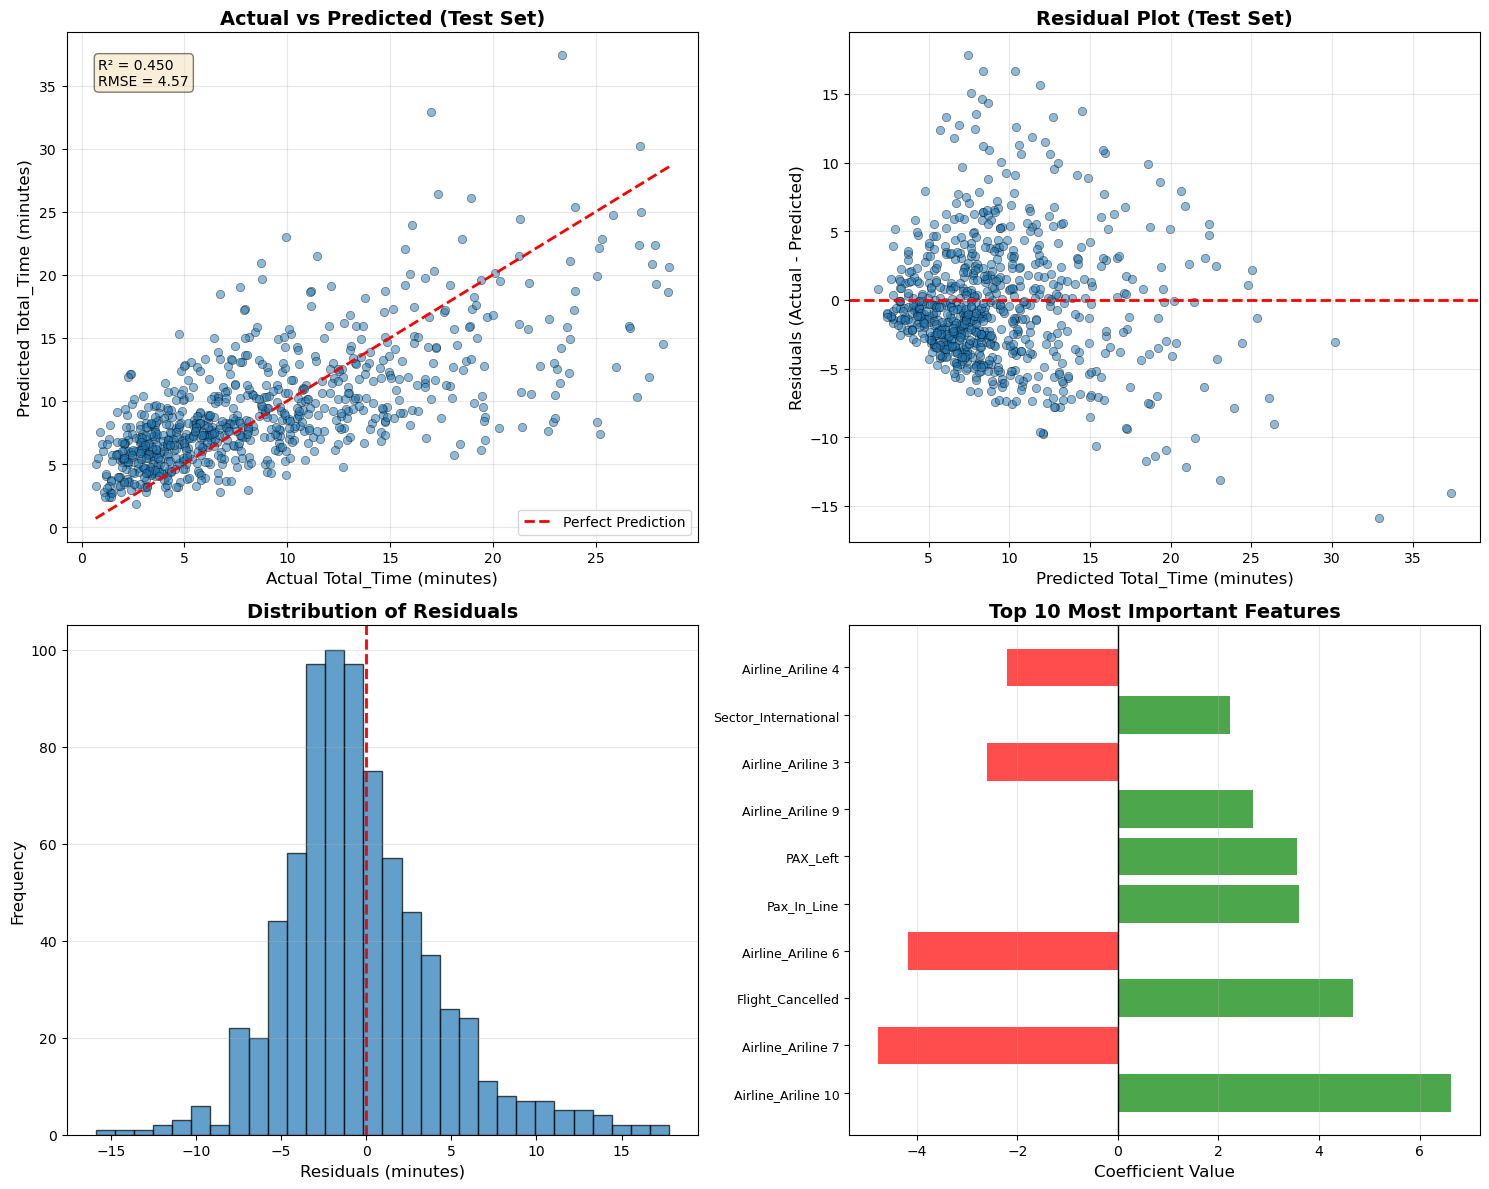

In [106]:
# Create a figure with multiple subplots
fig, axes = plt.subplots(2,2, figsize=(15, 12))

# Actual vs Predicted (Test Set)
axes[0,0].scatter(y_test, y_test_pred, alpha = 0.5, edgecolor='k', linewidth=0.5)
axes[0,0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw = 2, label='Perfect Prediction')
axes[0,0].set_xlabel('Actual Total_Time (minutes)', fontsize=12)
axes[0,0].set_ylabel('Predicted Total_Time (minutes)', fontsize=12)
axes[0,0].set_title('Actual vs Predicted (Test Set)', fontsize=14, fontweight='bold')
axes[0,0].legend()
axes[0,0].grid(True, alpha = 0.3)
axes[0, 0].text(0.05, 0.95, f'R² = {test_r2:.3f}\nRMSE = {test_rmse:.2f}', 
                transform=axes[0, 0].transAxes, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Residual Plot
axes[0, 1].scatter(y_test_pred, residuals, alpha=0.5, edgecolors='k', linewidth=0.5)
axes[0, 1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[0, 1].set_xlabel('Predicted Total_Time (minutes)', fontsize=12)
axes[0, 1].set_ylabel('Residuals (Actual - Predicted)', fontsize=12)
axes[0, 1].set_title('Residual Plot (Test Set)', fontsize=14, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# Residual Distribution
axes[1, 0].hist(residuals, bins=30, edgecolor='black', alpha=0.7)
axes[1, 0].axvline(x=0, color='r', linestyle='--', lw=2)
axes[1, 0].set_xlabel('Residuals (minutes)', fontsize=12)
axes[1, 0].set_ylabel('Frequency', fontsize=12)
axes[1, 0].set_title('Distribution of Residuals', fontsize=14, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Feature Importance (Top 10 coefficients by magnitude)
top_features = coef_df.head(10)
colors = ['green' if x > 0 else 'red' for x in top_features['Coefficient']]
axes[1, 1].barh(range(len(top_features)), top_features['Coefficient'], color=colors, alpha=0.7)
axes[1, 1].set_yticks(range(len(top_features)))
axes[1, 1].set_yticklabels(top_features['Feature'], fontsize=9)
axes[1, 1].set_xlabel('Coefficient Value', fontsize=12)
axes[1, 1].set_title('Top 10 Most Important Features', fontsize=14, fontweight='bold')
axes[1, 1].axvline(x=0, color='black', linestyle='-', lw=1)
axes[1, 1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('../reports/figures/model_evaluation_plots.png', dpi=300, bbox_inches='tight')